In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-08-27

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.16.1



# Librerias

In [2]:
%load_ext cuml.accel
import pandas as pd
import numpy as np
import joblib
from scipy.sparse import load_npz
from sentence_transformers import SentenceTransformer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score, roc_auc_score,matthews_corrcoef,classification_report,confusion_matrix,brier_score_loss,ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from pathlib import Path
ruta_base = Path.cwd()

# Cargar recursos necesarios

In [3]:
ruta_base

PosixPath('/espacio_trabajo/Analisis de datos y entrenamiento de modelos')

### Cargar Modelos Finales Y Vectorizadores

In [4]:
#Cargar Modelos
modelo_tfidf = joblib.load(ruta_base/ "Modelos Finales/modelo_tfidf.pkl")
modelo_embeddings = joblib.load(ruta_base/ "Modelos Finales/modelo_embeddings.pkl")

VECTORIZADOR_TFIDF = joblib.load(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_2/30000/vectorizador_tfidf")
VECTORIZADOR_EMBEDDINGS = SentenceTransformer(str(ruta_base/"Recursos de procesamiento de texto/multilingual-e5-base"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

# Cargar Matrices y Embeddings
(Las Matrices y Embeddings se escogieron en base a los mejores modelos experimentales, se escoje el modelo embeddings sin correción otrográfica debido a que las mejoras en rendimiento son minimas y no compensan la complejidad del modelo)

In [5]:
X_train_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_2/20000/X_train_tfidf.npz")).astype(np.float32)
X_validation_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_2/20000/X_validation_tfidf.npz")).astype(np.float32)
X_test_tfidf = (load_npz(ruta_base / "matrices y embeddings/No Ortografia/Matrices TF-IDF/sublinear_false/ngram_2/20000/X_test_tfidf.npz")).astype(np.float32)

X_train_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_train_embeddings.npy")).astype(np.float32)
X_validation_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_validation_embeddings.npy")).astype(np.float32)
X_test_embeddings = (np.load(ruta_base / "matrices y embeddings/No Ortografia/Embeddings/X_test_embeddings.npy")).astype(np.float32)

y_train = (np.load("./Y/y_train.npy")).astype(np.int32)
y_validation = (np.load("./Y/y_validation.npy")).astype(np.int32)
y_test = (np.load("./Y/y_test.npy")).astype(np.int32)

# Clases Adaptadoras

In [6]:
class TfidfAdaptador(BaseEstimator, ClassifierMixin):

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        X_tfidf = X[0]
        return self.model.predict(X_tfidf)

    def predict_proba(self, X):
        X_tfidf = X[0]
        return self.model.predict_proba(X_tfidf)


class EmbeddingAdaptador(BaseEstimator, ClassifierMixin):

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        X_embeddings = X[1]
        return self.model.predict(X_embeddings)

    def predict_proba(self, X):
        X_embeddings = X[1]
        return self.model.predict_proba(X_embeddings)

In [7]:
tfidf_adapter = TfidfAdaptador(modelo_tfidf)
embedding_adapter = EmbeddingAdaptador(modelo_embeddings)

# Modelo Ensemble

In [8]:
def crear_ensemble(weights=(1, 1)):
    ensamble = VotingClassifier(
        estimators=[
            ("tfidf", tfidf_adapter),
            ("embedding", embedding_adapter),
        ],
        voting="soft",
        weights=weights
    )

    ensamble.estimators_ = [tfidf_adapter, embedding_adapter]
    ensamble.classes_ = modelo_tfidf.classes_

    le = LabelEncoder()
    le.classes_ = modelo_tfidf.classes_
    ensamble.le_ = le

    return ensamble

ensamble_11 = crear_ensemble((1, 1))
ensamble_12 = crear_ensemble((1, 2))
ensamble_13 = crear_ensemble((1, 3))

# Métricas

In [9]:
def metricas_ensamble(X, y, ensamble):
    """
    Calcula diferentes métricas de clasificación para un modelo de ensamble, incluyendo su reporte de clasificación y matriz de confusión.

    Args:
        X: Datos de entrada utilizados para realizar las predicciones.
        y: Valores reales de las clases.
        ensamble: Modelo de ensamble entrenado.

    Returns:
        Reporte de clasificación, matriz de confusión y DataFrame con las métricas de evaluación del modelo de ensamble.
    """
    y_pred = ensamble.predict(X)
    y_proba = ensamble.predict_proba(X)

    exactitud = accuracy_score(y_true=y,y_pred=y_pred)
    precision_macro = precision_score(y_true=y,y_pred=y_pred,average="macro")
    f1_macro = f1_score(y_true=y,y_pred=y_pred,average="macro")
    recall_macro = recall_score(y_true=y,y_pred=y_pred,average="macro")
    roc_auc_ovc = roc_auc_score(y_true=y,y_score=y_proba,multi_class="ovr")
    perdida_brier_score_0 = brier_score_loss(y_true=(y == 0).astype(int),y_proba=y_proba[:, 0])
    perdida_brier_score_1 = brier_score_loss(y_true=(y == 1).astype(int),y_proba=y_proba[:, 1])
    perdida_brier_score_2 = brier_score_loss(y_true=(y == 2).astype(int),y_proba=y_proba[:, 2])
    coeficiente_matthew = matthews_corrcoef(y_true=y,y_pred=y_pred)

    dict_metricas = {
        "Exactitud": exactitud,
        "Precision_macro": precision_macro,
        "F1_macro": f1_macro,
        "Recall_macro": recall_macro,
        "ROC_auc_ovc": roc_auc_ovc,
        "Perdida_brier_score_0": perdida_brier_score_0,
        "Perdida_brier_score_1": perdida_brier_score_1,
        "Perdida_brier_score_2": perdida_brier_score_2,
        "Coeficiente_matthew": coeficiente_matthew,
    }

    df_metricas = pd.DataFrame(data=dict_metricas,index=["Ensamble"])

    reporte_clasificacion_dict = classification_report(y_true=y,y_pred=y_pred,output_dict=True)
    reporte_clasificacion = pd.DataFrame(reporte_clasificacion_dict).transpose()

    matriz_confusion = ConfusionMatrixDisplay(confusion_matrix(y_true=y,y_pred=y_pred))

    return reporte_clasificacion, matriz_confusion, df_metricas


In [10]:
reporte_ensamble_11, matriz_ensamble_11, metricas_ensamble_df_11 = metricas_ensamble(X=(X_validation_tfidf, X_validation_embeddings),y=y_validation,ensamble=ensamble_11)

reporte_ensamble_12, matriz_ensamble_12, metricas_ensamble_df_12 = metricas_ensamble(X=(X_validation_tfidf, X_validation_embeddings),y=y_validation,ensamble=ensamble_12)

reporte_ensamble_13, matriz_ensamble_13, metricas_ensamble_df_13 = metricas_ensamble(X=(X_validation_tfidf, X_validation_embeddings),y=y_validation,ensamble=ensamble_13)

metricas_comparacion_validation = pd.concat(
    [
        metricas_ensamble_df_11.rename(index={"Ensamble": "Ensemble 1:1"}),
        metricas_ensamble_df_12.rename(index={"Ensamble": "Ensemble 1:2"}),
        metricas_ensamble_df_13.rename(index={"Ensamble": "Ensemble 1:3"}),
    ]
)

In [11]:
metricas_comparacion_validation.T

,Ensemble 1:1,Ensemble 1:2,Ensemble 1:3
Exactitud,0.749499,0.753304,0.752103
Precision_macro,0.682634,0.689747,0.688348
F1_macro,0.659505,0.666375,0.666182
Recall_macro,0.666207,0.671709,0.671208
ROC_auc_ovc,0.877618,0.881320,0.881671
Perdida_brier_score_0,0.106766,0.105349,0.105404
Perdida_brier_score_1,0.137019,0.135765,0.135636
Perdida_brier_score_2,0.096025,0.093914,0.093681
Coeficiente_matthew,0.603976,0.610163,0.608154


In [ ]:
reporte_ensamble_12, matriz_ensamble_12, metricas_ensamble_df_12 = metricas_ensamble(X=(X_test_tfidf, X_test_embeddings),y=y_test,ensamble=ensamble_12)
metricas_ensamble_df_12.T

,Ensamble
Exactitud,0.758413
Precision_macro,0.695874
F1_macro,0.672076
Recall_macro,0.676950
ROC_auc_ovc,0.888483
Perdida_brier_score_0,0.102992
Perdida_brier_score_1,0.133908
Perdida_brier_score_2,0.090882
Coeficiente_matthew,0.618432


# Conclusion Tabla

El rendimiento del ensamble respecto a el modelo Embeddings no presenta una mejora significativa en todas sus metricas.

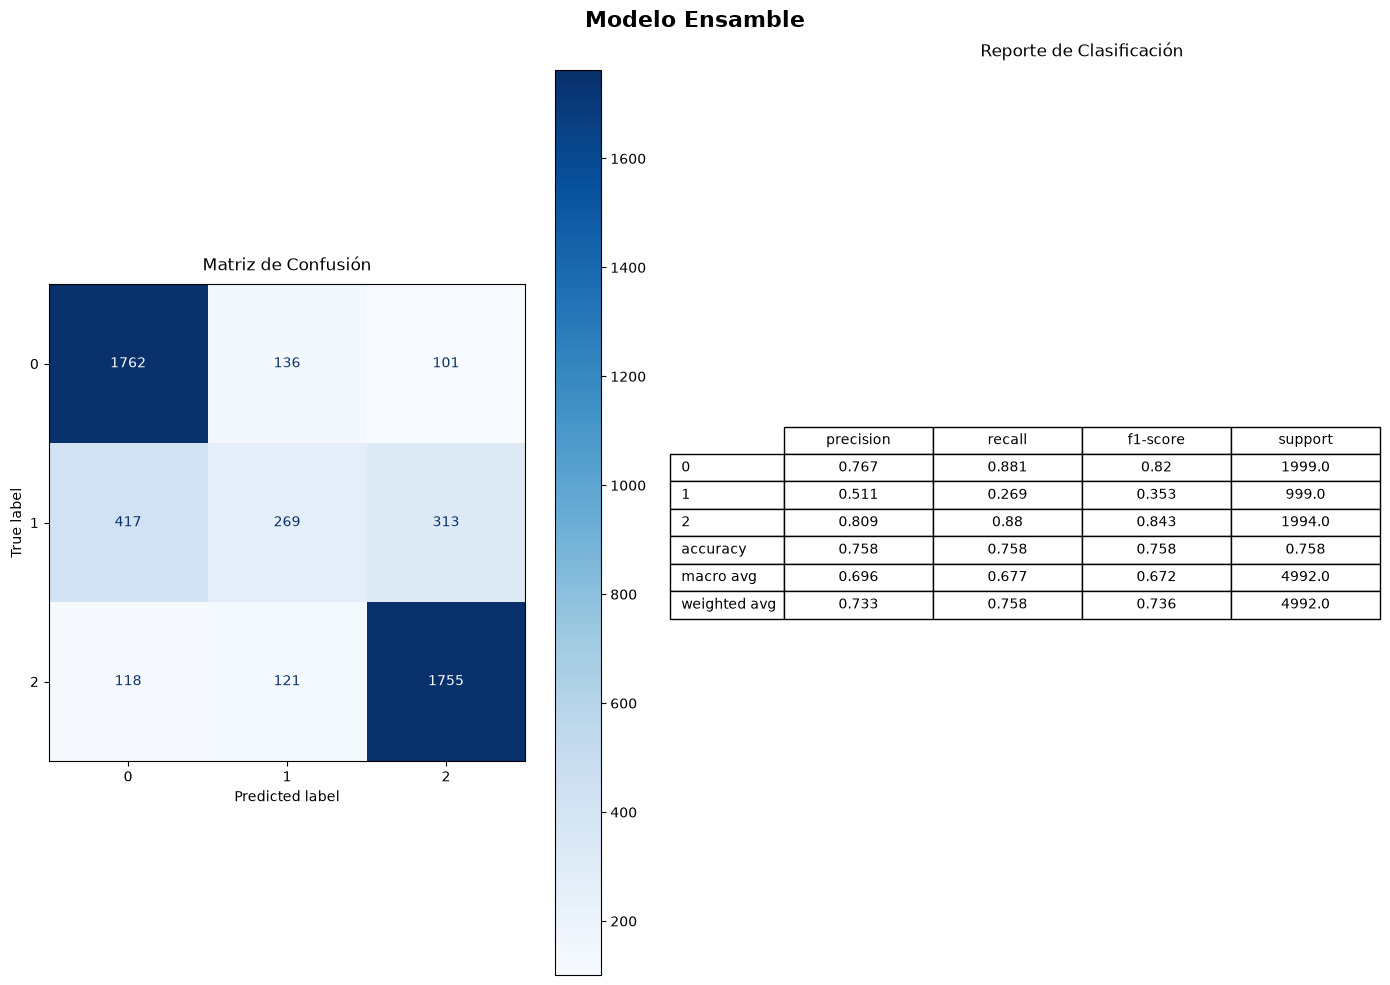

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 10))

fig.suptitle("Modelo Ensamble", fontsize=16, weight="bold", y=0.98)

# Matriz
matriz_ensamble_13.plot(ax=axs[0], cmap="Blues", values_format="d")
axs[0].set_title(f"Matriz de Confusión", fontsize=12, pad=10)

# Reporte
axs[1].axis("off")
tabla1 = axs[1].table(
    cellText=reporte_ensamble_12.values.round(3), # Añadido .round(3) para consistencia
    colLabels=reporte_ensamble_12.columns,
    rowLabels=reporte_ensamble_12.index,
    cellLoc="center",
    loc="center",
)
tabla1.scale(1, 1.4)
axs[1].set_title(f"Reporte de Clasificación", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

## Conclusión - Matriz de confusión y Reporte de clasificación
#### Matriz de confusion
* El modelo ensamble detectó menos valores neutros que el Modelo Embeddings, lo que puede indicar que el modelo ensamble no representa alguna solucion a esta clase.
#### Reporte de clasificación
* El modelo presentó una presición en la clase 1 muy similar a el modelo embeddings. Lo que no muestra mejora en la solucion a el problema de la clase 1 o clase neutra

# Guardando Modelo Ensamble

In [ ]:
joblib.dump(ensamble_12, filename= ruta_base / "Modelos Finales/modelo_ensamble.pkl")

['/espacio_trabajo/Analisis de datos y entrenamiento de modelos/Modelos Finales/modelo_ensamble.pkl']